In [2]:
import qiskit
from qiskit.quantum_info import Operator
from qiskit.quantum_info import Statevector
from qiskit import QuantumCircuit
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
import math
import numpy as np
from qiskit.circuit.library import HGate
from qiskit.circuit.library import TGate
from qiskit.circuit.library import SGate
from qiskit.circuit.library import SwapGate
from os import error
from qiskit import transpile
from qiskit.visualization import plot_distribution

In [3]:
def QRC(qc):
  gate_control = qc.qregs[0]
  target = qc.qregs[2]

  global x_gate_qrc
  global ccc_h_qrc
  global ccc_t_qrc
  global ccc_s_qrc
  global cccc_not_qrc

  #00
  qc.x(1)
  qc.x(2)

  #11
  c3h_gate = HGate().control(3)
  qc.append(c3h_gate, [gate_control[0],gate_control[1],gate_control[2],target[0]])

  qc.x(1)

  #01
  t3h_gate = TGate().control(3)
  qc.append(t3h_gate, [gate_control[0],gate_control[1],gate_control[2],target[0]])

  qc.x(1)
  qc.x(2)

  #10
  s3h_gate = SGate().control(3)
  qc.append(s3h_gate, [gate_control[0],gate_control[1],gate_control[2],target[0]])

  qc.x(1)

  #00
  qc.mcx([gate_control[0],gate_control[1],gate_control[2],target[0]],target[1])

  x_gate_qrc = x_gate_qrc + 6
  ccc_h_qrc = ccc_h_qrc + 1
  ccc_t_qrc = ccc_t_qrc + 1
  ccc_s_qrc = ccc_s_qrc + 1
  cccc_not_qrc = cccc_not_qrc + 1

  qc.barrier()


In [4]:
def QRC_Gray_Code(qc):
  gate_control = qc.qregs[0]
  target = qc.qregs[2]

  global x_gate_qrc
  global ccc_h_qrc
  global ccc_t_qrc
  global ccc_s_qrc
  global cccc_not_qrc

  #00
  qc.mcx([gate_control[0],gate_control[1],gate_control[2],target[0]],target[1])

  qc.x(2)

  #01
  t3h_gate = TGate().control(3)
  qc.append(t3h_gate, [gate_control[0],gate_control[1],gate_control[2],target[0]])

  qc.x(1)

  #11
  c3h_gate = HGate().control(3)
  qc.append(c3h_gate, [gate_control[0],gate_control[1],gate_control[2],target[0]])

  qc.x(2)

  #10
  s3h_gate = SGate().control(3)
  qc.append(s3h_gate, [gate_control[0],gate_control[1],gate_control[2],target[0]])

  qc.x(1)

  #00

  x_gate_qrc = x_gate_qrc + 6
  ccc_h_qrc = ccc_h_qrc + 1
  ccc_t_qrc = ccc_t_qrc + 1
  ccc_s_qrc = ccc_s_qrc + 1
  cccc_not_qrc = cccc_not_qrc + 1

  qc.barrier()


In [5]:
def Swap_Gate(qc):
  gate_control = qc.qregs[0]
  swap_control = qc.qregs[1]
  target = qc.qregs[2]
  n = len(target)

  #qc.x(gate_control[0])

  #mc_swap = SwapGate().control(3)
  #qc.append(mc_swap, [gate_control[0], swap_control[len(swap_control) - 2], swap_control[len(swap_control) - 1], target[0], target[1]])

  global x_gate_qrc
  global cc_swap_on_n_qubits_qrc
  global swap_control_state

  for j in range(2 ** (len(swap_control) - 1)):
    for k in range(len(swap_control) - 1):
      if(j % (2 ** k) == 0):
        qc.x(swap_control[k + 1])
        x_gate_qrc = x_gate_qrc + 1
        swap_control_state[k + 1] ^= 1

    if(j >= n - 1):
      continue

    controls = [swap_control[k] for k in range(len(swap_control))]
    mc_swap = SwapGate().control(len(controls))
    qc.append(mc_swap, controls + [target[0], target[j + 1]])
    cc_swap_on_n_qubits_qrc = cc_swap_on_n_qubits_qrc + 1

  qc.barrier()

  #qc.x(swap_control[len(swap_control) - 1])

  #mc_swap = SwapGate().control(3)
  #qc.append(mc_swap, [gate_control[0], swap_control[len(swap_control) - 2], swap_control[len(swap_control) - 1], target[0], target[1]])

  #qc.x(gate_control[0])
  #qc.x(swap_control[len(swap_control) - 1])

In [6]:
def Reverse_Swap_Gate(qc):
  gate_control = qc.qregs[0]
  swap_control = qc.qregs[1]
  target = qc.qregs[2]
  n = len(target)

  global x_gate_qrc
  global cc_swap_on_n1_qubits_qrc
  global swap_control_state

  for j in range(2 ** (len(swap_control) - 1)):
    for k in range(len(swap_control) - 1):
      if(j % (2 ** k) == 0):
        qc.x(swap_control[k + 1])
        x_gate_qrc = x_gate_qrc + 1
        swap_control_state[k + 1] ^= 1

    if(j >= n - 1):
      continue

    controls = [swap_control[k] for k in range(len(swap_control))] + [gate_control[0]]
    mc_swap = SwapGate().control(len(controls))
    qc.append(mc_swap, controls + [target[0], target[j + 1]])
    cc_swap_on_n1_qubits_qrc = cc_swap_on_n1_qubits_qrc + 1

  qc.barrier()

In [7]:
def print_controls(qc, label=""):
    gate_control = qc.qregs[0]
    swap_control = qc.qregs[1]

    sv = Statevector.from_instruction(qc)

    gate_bits = []
    for q in gate_control:
        idx = qc.find_bit(q).index
        probs = sv.probabilities([idx])
        gate_bits.append("0" if probs[0] > 0.999 else "1")

    swap_bits = []
    for q in swap_control:
        idx = qc.find_bit(q).index
        probs = sv.probabilities([idx])
        swap_bits.append("0" if probs[0] > 0.999 else "1")

    print(
        f"{label:<20} "
        f"gate={''.join(gate_bits)} "
        f"swap={''.join(swap_bits)}"
    )

In [8]:
def Apply_Gate(qc):

  #print_controls(qc)
  global gate_control_state
  global swap_control_state
  global reconfigurable_cell_count
  reconfigurable_cell_count = reconfigurable_cell_count + 1
  
  print("QRC: " + str(reconfigurable_cell_count) + " Gate Control Qubits: " + str(gate_control_state) + " Swap Control Qubits: " + str(swap_control_state))

  #Apply the Swap block  
  Swap_Gate(qc)

  #Apply the QRC block
  QRC(qc)

  #Apply the Reverse Swap block
  Reverse_Swap_Gate(qc)

In [ ]:
n = 4

gate_control = QuantumRegister(3, "gate_control")
swap_control = QuantumRegister(1 + math.ceil(math.log2(n - 1)), "swap_control")
target = QuantumRegister(n, "target")

measurement = ClassicalRegister(n, "measurement")

qc = QuantumCircuit(gate_control, swap_control, target, measurement)

x_gate_qrc = 0
cc_swap_qrc = 0
cc_swap_on_n_qubits_qrc = 0
cc_swap_on_n1_qubits_qrc = 0
ccc_h_qrc = 0
ccc_t_qrc = 0
ccc_s_qrc = 0
cccc_not_qrc = 0
reconfigurable_cell_count = 0
gate_control_state = [0] * len(gate_control)
swap_control_state = [0] * len(swap_control)

Apply_Gate(qc)

print("qubits = " + str(3 + 1 + math.ceil(math.log2(n - 1) + n)))
print("x_gate_qrc = " + str(x_gate_qrc))
print("cc_swap_qrc = " + str(cc_swap_qrc))
print("cc_swap_on_n_qubits_qrc = " + str(cc_swap_on_n_qubits_qrc))
print("cc_swap_on_n1_qubits_qrc = " + str(cc_swap_on_n1_qubits_qrc))
print("ccc_h_qrc = " + str(ccc_h_qrc))
print("ccc_t_qrc = " + str(ccc_t_qrc))
print("ccc_s_qrc = " + str(ccc_s_qrc))
print("cccc_not_qrc = " + str(cccc_not_qrc))
print("reconfigurable_cell_count = " + str(reconfigurable_cell_count))

qc.draw(output="mpl")

NameError: name 'gate_control_state' is not defined

In [17]:
def Modify_Swap_Control_Bits(qc, target_qubit):
  swap_control = qc.qregs[1]

  global x_gate_qrc
  global swap_control_state

  if(target_qubit == 0):
    qc.x(swap_control[0])
    x_gate_qrc = x_gate_qrc + 1
    swap_control_state[0] ^= 1
    return

  number_of_bits = len(swap_control) - 2
  binary = format(target_qubit - 1, f'0{number_of_bits}b')

  bit_id = 0

  for bit in reversed(binary):
    bit_id = bit_id + 1
    if bit == '1':
      qc.x(swap_control[bit_id])
      x_gate_qrc = x_gate_qrc + 1
      swap_control_state[bit_id] ^= 1

In [18]:
def NOP_Gate(qc, target_qubit):
  gate_control = qc.qregs[0]

  global x_gate_qrc
  global gate_control_state

  #Apply X on gate qubits
  qc.x(gate_control[0])
  gate_control_state[0] ^= 1
  x_gate_qrc = x_gate_qrc + 1

  #Apply X on swap qubits
  Modify_Swap_Control_Bits(qc, target_qubit)
  qc.barrier()
  #qc.x(swap_control[target_qubit])

  #Apply Swap, QRC and Reverser-Swap
  Apply_Gate(qc)

  #Restore swap qubits
  Modify_Swap_Control_Bits(qc, target_qubit)
  qc.barrier()
  #qc.x(swap_control[target_qubit])

  #Restore gate qubits
  qc.x(gate_control[0])
  gate_control_state[0] ^= 1
  x_gate_qrc = x_gate_qrc + 1

In [19]:
def H_Gate(qc, target_qubit):
  swap_control = qc.qregs[1]

  #Apply X on gate qubits
  #Nothing to do for H Gate

  #Apply X on swap qubits
  #qc.x(swap_control[target_qubit])
  Modify_Swap_Control_Bits(qc, target_qubit)
  qc.barrier()

  #Apply Swap, QRC and Reverser-Swap
  Apply_Gate(qc)

  #Restore swap qubits
  #qc.x(swap_control[target_qubit])
  Modify_Swap_Control_Bits(qc, target_qubit)
  qc.barrier()

  #Restore gate qubits
  #Nothing to do for H Gate

In [20]:
def T_Gate(qc, target_qubit):
  gate_control = qc.qregs[0]
  swap_control = qc.qregs[1]

  global x_gate_qrc
  global gate_control_state

  #Apply X on gate qubits
  qc.x(gate_control[1])
  gate_control_state[1] ^= 1
  x_gate_qrc = x_gate_qrc + 1

  #Apply X on swap qubits
  #qc.x(swap_control[target_qubit])
  Modify_Swap_Control_Bits(qc, target_qubit)
  qc.barrier()

  #Apply Swap, QRC and Reverser-Swap
  Apply_Gate(qc)

  #Restore swap qubits
  #qc.x(swap_control[target_qubit])
  Modify_Swap_Control_Bits(qc, target_qubit)
  qc.barrier()

  #Restore gate qubits
  qc.x(gate_control[1])
  gate_control_state[1] ^= 1
  x_gate_qrc = x_gate_qrc + 1

In [21]:
def S_Gate(qc, target_qubit):
  gate_control = qc.qregs[0]
  swap_control = qc.qregs[1]

  global x_gate_qrc
  global gate_control_state

  #Apply X on gate qubits
  qc.x(gate_control[2])
  gate_control_state[2] ^= 1
  x_gate_qrc = x_gate_qrc + 1

  #Apply X on swap qubits
  #qc.x(swap_control[target_qubit])
  Modify_Swap_Control_Bits(qc, target_qubit)
  qc.barrier()

  #Apply Swap, QRC and Reverser-Swap
  Apply_Gate(qc)

  #Restore swap qubits
  #qc.x(swap_control[target_qubit])
  Modify_Swap_Control_Bits(qc, target_qubit)
  qc.barrier()

  #Restore gate qubits
  qc.x(gate_control[2])
  gate_control_state[2] ^= 1
  x_gate_qrc = x_gate_qrc + 1

In [22]:
def CNOT_Gate(qc, control_qubit, target_qubit):
  gate_control = qc.qregs[0]
  swap_control = qc.qregs[1]
  
  global x_gate_qrc
  global gate_control_state

  if(control_qubit == target_qubit):
    raise ValueError(f"Error: Control and target qubits of the CNOT gate must be different!")

  #if we want to apply CNOT with target on the second position, we don't have to make the NOP to move the target,
  #due to it already being in the correct position
  if(target_qubit != 1):
    #if the control qubit is on the first position, than after the swaps made on the target qubit it will be left
    #in the place of the target qubit and we need to adjust the value of the control qubit to know which qubit
    #needs to be swapped back to the first position
    if(control_qubit == 0):
      control_qubit = target_qubit

    #if the control qubit is on the second position, than after the swaps made on the target qubit it will be left
    #on the first position and we need to adjust the value of the control qubit to know which qubit needs to be
    #swapped back to the first position
    if(control_qubit == 1):
      control_qubit = 0

    #Apply NOP to move target qubit to the first position
    NOP_Gate(qc, target_qubit)

    #Apply NOP to move target to the second position
    NOP_Gate(qc, 1)

  #Apply CNOT gate
  #Apply X on gate qubits
  qc.x(gate_control[1])
  qc.x(gate_control[2])
  gate_control_state[1] ^= 1
  gate_control_state[2] ^= 1
  x_gate_qrc = x_gate_qrc + 2

  #Apply X on swap qubits
  #qc.x(swap_control[control_qubit])
  Modify_Swap_Control_Bits(qc, control_qubit)
  qc.barrier()

  #Apply Swap, QRC and Reverser-Swap
  Apply_Gate(qc)

  #Restore swap qubits
  #qc.x(swap_control[control_qubit])
  Modify_Swap_Control_Bits(qc, control_qubit)
  qc.barrier()

  #Restore gate qubits
  qc.x(gate_control[1])
  qc.x(gate_control[2])
  gate_control_state[1] ^= 1
  gate_control_state[2] ^= 1
  x_gate_qrc = x_gate_qrc + 2

  if(target_qubit != 1):
    #Apply NOP to move target back to the first position
    NOP_Gate(qc, 1)

    #Apply NOP to move target back to the original position
    NOP_Gate(qc, target_qubit)

In [23]:
def Z_Gate(qc, target_qubit):
  S_Gate(qc, target_qubit)
  S_Gate(qc, target_qubit)

In [24]:
def X_Gate(qc, target_qubit):
  H_Gate(qc, target_qubit)
  Z_Gate(qc, target_qubit)
  H_Gate(qc, target_qubit)

In [25]:
def T_Dagger_Gate(qc, target_qubit):
  Z_Gate(qc, target_qubit)
  S_Gate(qc, target_qubit)
  T_Gate(qc, target_qubit)

In [26]:
def Toffoli_Gate(qc, control_qubit_1, control_qubit_2, target_qubit):
  T_Dagger_Gate(qc, control_qubit_1)
  T_Dagger_Gate(qc, control_qubit_2)
  H_Gate(qc, target_qubit)

  CNOT_Gate(qc, target_qubit, control_qubit_1)

  T_Gate(qc, control_qubit_1)
  CNOT_Gate(qc, control_qubit_2, target_qubit)

  CNOT_Gate(qc, control_qubit_2, control_qubit_1)
  T_Gate(qc, target_qubit)

  T_Dagger_Gate(qc, control_qubit_1)
  CNOT_Gate(qc, control_qubit_2, target_qubit)

  CNOT_Gate(qc, target_qubit, control_qubit_1)

  T_Gate(qc, control_qubit_1)
  T_Dagger_Gate(qc, target_qubit)

  CNOT_Gate(qc, control_qubit_2, control_qubit_1)
  H_Gate(qc, target_qubit)

In [27]:
def Toffoli_Gate_3(qc, control_qubits, target_qubit, ancilla_qubit):
  Toffoli_Gate(qc, control_qubits[0], control_qubits[1], ancilla_qubit)
  Toffoli_Gate(qc, control_qubits[2], ancilla_qubit, target_qubit)
  Toffoli_Gate(qc, control_qubits[0], control_qubits[1], ancilla_qubit)

In [28]:
def Toffoli_Gate_4(qc, control_qubits, target_qubit, ancilla_qubit):
    Toffoli_Gate(qc, control_qubits[0], control_qubits[2], ancilla_qubit)
    Toffoli_Gate(qc, control_qubits[2], ancilla_qubit, target_qubit)

    Toffoli_Gate(qc, control_qubits[1], control_qubits[3], control_qubits[2])
    Toffoli_Gate(qc, control_qubits[2], ancilla_qubit, target_qubit)

    Toffoli_Gate(qc, control_qubits[1], control_qubits[3], control_qubits[2])
    Toffoli_Gate(qc, control_qubits[0], control_qubits[2], ancilla_qubit)

In [29]:
def Toffoli_Gate_5(qc, control_qubits, target_qubit, ancilla_qubit):
    Toffoli_Gate(qc, control_qubits[3], control_qubits[4], ancilla_qubit)
    Toffoli_Gate(qc, control_qubits[0], control_qubits[2], control_qubits[3])
    Toffoli_Gate(qc, control_qubits[3], control_qubits[4], ancilla_qubit)
    Toffoli_Gate(qc, control_qubits[0], control_qubits[2], control_qubits[3])

    Toffoli_Gate(qc, control_qubits[2], ancilla_qubit, target_qubit)
    Toffoli_Gate(qc, control_qubits[1], control_qubits[3], control_qubits[2])
    Toffoli_Gate(qc, control_qubits[2], ancilla_qubit, target_qubit)
    Toffoli_Gate(qc, control_qubits[1], control_qubits[3], control_qubits[2])

    Toffoli_Gate(qc, control_qubits[3], control_qubits[4], ancilla_qubit)
    Toffoli_Gate(qc, control_qubits[0], control_qubits[2], control_qubits[3])
    Toffoli_Gate(qc, control_qubits[3], control_qubits[4], ancilla_qubit)
    Toffoli_Gate(qc, control_qubits[0], control_qubits[2], control_qubits[3])

In [30]:
def Toffoli_Gate_6(qc, control_qubits, target_qubit, ancilla_qubit):
    Toffoli_Gate(qc, control_qubits[3], control_qubits[4], ancilla_qubit)
    Toffoli_Gate(qc, control_qubits[0], control_qubits[2], control_qubits[3])
    Toffoli_Gate(qc, control_qubits[3], control_qubits[4], ancilla_qubit)
    Toffoli_Gate(qc, control_qubits[0], control_qubits[2], control_qubits[3])

    Toffoli_Gate(qc, control_qubits[4], ancilla_qubit, target_qubit)
    Toffoli_Gate(qc, control_qubits[2], control_qubits[5], control_qubits[4])
    Toffoli_Gate(qc, control_qubits[1], control_qubits[3], control_qubits[2])
    Toffoli_Gate(qc, control_qubits[2], control_qubits[5], control_qubits[4])
    Toffoli_Gate(qc, control_qubits[4], ancilla_qubit, target_qubit)
    Toffoli_Gate(qc, control_qubits[2], control_qubits[5], control_qubits[4])
    Toffoli_Gate(qc, control_qubits[1], control_qubits[3], control_qubits[2])
    Toffoli_Gate(qc, control_qubits[2], control_qubits[5], control_qubits[4])

    Toffoli_Gate(qc, control_qubits[3], control_qubits[4], ancilla_qubit)
    Toffoli_Gate(qc, control_qubits[0], control_qubits[2], control_qubits[3])
    Toffoli_Gate(qc, control_qubits[3], control_qubits[4], ancilla_qubit)
    Toffoli_Gate(qc, control_qubits[0], control_qubits[2], control_qubits[3])

In [31]:
def Toffoli_Gate_7(qc, control_qubits, target_qubit, ancilla_qubit):
  Toffoli_Gate(qc, control_qubits[5], control_qubits[6], ancilla_qubit)
  Toffoli_Gate(qc, control_qubits[3], control_qubits[4], control_qubits[5])
  Toffoli_Gate(qc, control_qubits[0], control_qubits[2], control_qubits[3])
  Toffoli_Gate(qc, control_qubits[3], control_qubits[4], control_qubits[5])
  Toffoli_Gate(qc, control_qubits[5], control_qubits[6], ancilla_qubit)
  Toffoli_Gate(qc, control_qubits[3], control_qubits[4], control_qubits[5])
  Toffoli_Gate(qc, control_qubits[0], control_qubits[2], control_qubits[3])
  Toffoli_Gate(qc, control_qubits[3], control_qubits[4], control_qubits[5])

  Toffoli_Gate(qc, control_qubits[6], ancilla_qubit, target_qubit)
  Toffoli_Gate(qc, control_qubits[2], control_qubits[5], control_qubits[6])
  Toffoli_Gate(qc, control_qubits[1], control_qubits[3], control_qubits[2])
  Toffoli_Gate(qc, control_qubits[2], control_qubits[5], control_qubits[6])
  Toffoli_Gate(qc, control_qubits[6], ancilla_qubit, target_qubit)
  Toffoli_Gate(qc, control_qubits[2], control_qubits[5], control_qubits[6])
  Toffoli_Gate(qc, control_qubits[1], control_qubits[3], control_qubits[2])
  Toffoli_Gate(qc, control_qubits[2], control_qubits[5], control_qubits[6])

  Toffoli_Gate(qc, control_qubits[5], control_qubits[6], ancilla_qubit)
  Toffoli_Gate(qc, control_qubits[3], control_qubits[4], control_qubits[5])
  Toffoli_Gate(qc, control_qubits[0], control_qubits[2], control_qubits[3])
  Toffoli_Gate(qc, control_qubits[3], control_qubits[4], control_qubits[5])
  Toffoli_Gate(qc, control_qubits[5], control_qubits[6], ancilla_qubit)
  Toffoli_Gate(qc, control_qubits[3], control_qubits[4], control_qubits[5])
  Toffoli_Gate(qc, control_qubits[0], control_qubits[2], control_qubits[3])
  Toffoli_Gate(qc, control_qubits[3], control_qubits[4], control_qubits[5])

In [32]:
def Toffoli_Gate_8(qc, control_qubits, target_qubit, ancilla_qubit):
  Toffoli_Gate(qc, control_qubits[5], control_qubits[6], ancilla_qubit)
  Toffoli_Gate(qc, control_qubits[3], control_qubits[4], control_qubits[5])
  Toffoli_Gate(qc, control_qubits[0], control_qubits[2], control_qubits[3])
  Toffoli_Gate(qc, control_qubits[3], control_qubits[4], control_qubits[5])
  Toffoli_Gate(qc, control_qubits[5], control_qubits[6], ancilla_qubit)
  Toffoli_Gate(qc, control_qubits[3], control_qubits[4], control_qubits[5])
  Toffoli_Gate(qc, control_qubits[0], control_qubits[2], control_qubits[3])
  Toffoli_Gate(qc, control_qubits[3], control_qubits[4], control_qubits[5])

  Toffoli_Gate(qc, control_qubits[6], ancilla_qubit, target_qubit)
  Toffoli_Gate(qc, control_qubits[2], control_qubits[7], control_qubits[6])
  Toffoli_Gate(qc, control_qubits[0], control_qubits[5], control_qubits[2])
  Toffoli_Gate(qc, control_qubits[1], control_qubits[3], control_qubits[0])
  Toffoli_Gate(qc, control_qubits[0], control_qubits[5], control_qubits[2])
  Toffoli_Gate(qc, control_qubits[2], control_qubits[7], control_qubits[6])
  Toffoli_Gate(qc, control_qubits[6], ancilla_qubit, target_qubit)
  Toffoli_Gate(qc, control_qubits[2], control_qubits[7], control_qubits[6])
  Toffoli_Gate(qc, control_qubits[0], control_qubits[5], control_qubits[2])
  Toffoli_Gate(qc, control_qubits[1], control_qubits[3], control_qubits[0])
  Toffoli_Gate(qc, control_qubits[0], control_qubits[5], control_qubits[2])
  Toffoli_Gate(qc, control_qubits[2], control_qubits[7], control_qubits[6])

  Toffoli_Gate(qc, control_qubits[5], control_qubits[6], ancilla_qubit)
  Toffoli_Gate(qc, control_qubits[3], control_qubits[4], control_qubits[5])
  Toffoli_Gate(qc, control_qubits[0], control_qubits[2], control_qubits[3])
  Toffoli_Gate(qc, control_qubits[3], control_qubits[4], control_qubits[5])
  Toffoli_Gate(qc, control_qubits[5], control_qubits[6], ancilla_qubit)
  Toffoli_Gate(qc, control_qubits[3], control_qubits[4], control_qubits[5])
  Toffoli_Gate(qc, control_qubits[0], control_qubits[2], control_qubits[3])
  Toffoli_Gate(qc, control_qubits[3], control_qubits[4], control_qubits[5])

In [34]:
def Reconfigurable_Oracle(qc, target_value):
  for i in range(len(target_value)):
    if(target_value[i] != '1'):
      X_Gate(qc, i)

  match len(target_value):
    case 3:
      Toffoli_Gate_3(qc, [0, 1, 2], 3, 4)
    case 4:
      Toffoli_Gate_4(qc, [0, 1, 2, 3], 4, 5)
    case 5:
      Toffoli_Gate_5(qc, [0, 1, 2, 3, 4], 5, 6)
    case 6:
      Toffoli_Gate_6(qc, [0, 1, 2, 3, 4, 5], 6, 7)
    case 7:
      Toffoli_Gate_7(qc, [0, 1, 2, 3, 4, 5, 6], 7, 8)
    case 8:
      Toffoli_Gate_8(qc, [0, 1, 2, 3, 4, 5, 6, 7], 8, 9)

  for i in range(len(target_value)):
    if(target_value[i] != '1'):
      X_Gate(qc, i)

In [35]:
def Reconfigurable_Diffuser(qc):
  n = len(qc.qregs[2]) - 2

  for i in range(n):
    H_Gate(qc, i)
    X_Gate(qc, i)

  H_Gate(qc, n-1)

  match n:
    case 2:
      CNOT_Gate(qc, 0, 1)
    case 3:
      Toffoli_Gate(qc, 0, 1, 2)
    case 4:
      Toffoli_Gate_3(qc, [0, 1, 2], 3, 5)
    case 5:
      Toffoli_Gate_4(qc, [0, 1, 2, 3], 4, 6)
    case 6:
      Toffoli_Gate_5(qc, [0, 1, 2, 3, 4], 5, 7)
    case 7:
      Toffoli_Gate_6(qc, [0, 1, 2, 3, 4, 5], 6, 8)
    case 8:
      Toffoli_Gate_7(qc, [0, 1, 2, 3, 4, 5, 6], 7, 9)

  H_Gate(qc, n-1)

  for i in range(n):
    X_Gate(qc, i)
    H_Gate(qc, i)

In [ ]:
#target_value = "110"
#target_value = "1101"
#target_value = "11010"
#target_value = "110100"
#target_value = "1101001"
target_value = "11010010"

n = len(target_value)

gate_control = QuantumRegister(3, "gate_control")
swap_control = QuantumRegister(1 + math.ceil(math.log2(n+1)), "swap_control")
target = QuantumRegister(n+1+1, "target")
measurement = ClassicalRegister(n+1+1, "measurement")

qc = QuantumCircuit(gate_control, swap_control, target, measurement)

x_gate_qrc = 0
cc_swap_qrc = 0
cc_swap_on_n_qubits_qrc = 0
cc_swap_on_n1_qubits_qrc = 0
ccc_h_qrc = 0
ccc_t_qrc = 0
ccc_s_qrc = 0
cccc_not_qrc = 0
reconfigurable_cell_count = 0

qc.x(gate_control[0])
qc.x(swap_control[0])
x_gate_qrc = x_gate_qrc + 2

#Start

X_Gate(qc, n)

for i in range(n+1):
  H_Gate(qc, i)

steps = math.sqrt(math.pow(2,n))
steps = round(math.pi/4 * steps)

print(steps)

for i in range(steps):
  Reconfigurable_Oracle(qc, target_value)
  Reconfigurable_Diffuser(qc)

H_Gate(qc, n)
X_Gate(qc, n)

#End

#CNOT_Gate(qc, 2, 4)

qc.x(gate_control[0])
qc.x(swap_control[0])
x_gate_qrc = x_gate_qrc + 2

qc.measure(target, range(n+1+1))

print("qubits = " + str(6 + math.ceil(math.log2(n+1) + n)))
print("x_gate_qrc = " + str(x_gate_qrc))
print("cc_swap_qrc = " + str(cc_swap_qrc))
print("cc_swap_on_" + str(1 + math.ceil(math.log2(n+1))) + "_qubits_qrc = " + str(cc_swap_on_n_qubits_qrc))
print("cc_swap_on_" + str(2 + math.ceil(math.log2(n+1))) + "_qubits_qrc = " + str(cc_swap_on_n1_qubits_qrc))
print("ccc_h_qrc = " + str(ccc_h_qrc))
print("ccc_t_qrc = " + str(ccc_t_qrc))
print("ccc_s_qrc = " + str(ccc_s_qrc))
print("cccc_not_qrc = " + str(cccc_not_qrc))
print("reconfigurable_cell_count = " + str(reconfigurable_cell_count))

#qc.draw("mpl")

13


KeyboardInterrupt: 

{'0000101101': 4, '0000110011': 2, '0011001100': 2, '0010011110': 2, '0001001011': 9864, '0000110001': 2, '0001111110': 1, '0000101110': 1, '0000000101': 1, '0001000011': 2, '0001000001': 1, '0000110000': 1, '0001000111': 3, '0000000001': 1, '0011100100': 1, '0001110010': 1, '0000100001': 1, '0011000110': 1, '0011101101': 1, '0011010110': 1, '0011101110': 1, '0011000111': 1, '0011110000': 1, '0001110001': 1, '0000100010': 2, '0010010011': 1, '0011101100': 2, '0011000001': 1, '0011000010': 3, '0000111011': 2, '0001010000': 1, '0000010100': 2, '0011101111': 1, '0011000100': 2, '0001001110': 2, '0001110000': 2, '0000001100': 2, '0000011001': 1, '0010001011': 1, '0001010101': 1, '0010001001': 2, '0001000110': 2, '0001111100': 1, '0000010001': 1, '0011110100': 1, '0000000011': 1, '0000101100': 1, '0010111100': 1, '0001010110': 1, '0010110000': 1, '0011111110': 1, '0010111001': 2, '0001100101': 1, '0011110110': 1, '0010100101': 2, '0011110101': 1, '0011111010': 1, '0011110011': 1, '000101010

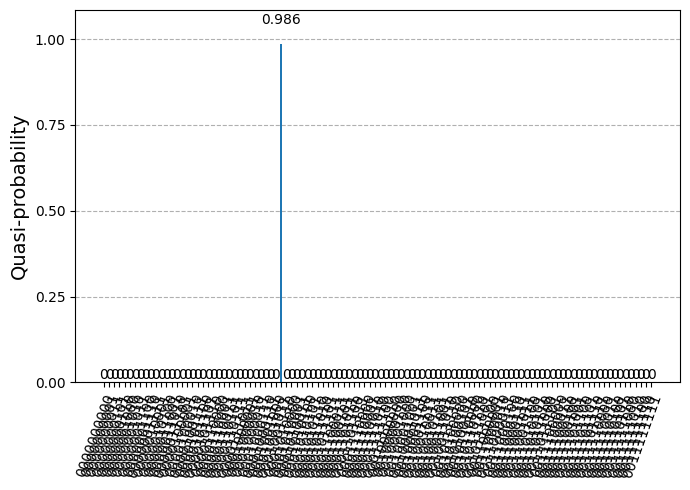

In [ ]:
from qiskit_aer import AerSimulator

sim = AerSimulator()
qc.measure(target, measurement)

qc_t = transpile(qc, sim, optimization_level=3)
result = sim.run(qc_t, shots=10_000).result()

counts = result.get_counts()
print(counts)

plot_distribution(counts)

In [36]:
#Half adder cell
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator

# q0=A, q1=B, q2=Sum, q3=Carry

n = 5

gate_control = QuantumRegister(3, "gate_control")
swap_control = QuantumRegister(1 + math.ceil(math.log2(n+1)), "swap_control")
target = QuantumRegister(n, "target")
measurement = ClassicalRegister(2, "measurement")

reconfigurable_cell_count = 0

qc = QuantumCircuit(gate_control, swap_control, target, measurement)

qc.x(gate_control[0])
qc.x(swap_control[0])

# Set inputs A=1, B=1
qc.x(target[0])
#qc.x(target[1])

# Half Adder
CNOT_Gate(qc, 0, 3)
CNOT_Gate(qc, 1, 3)
Toffoli_Gate(qc, 0, 1, 4)

qc.x(gate_control[0])
qc.x(swap_control[0])

# Measure outputs only
qc.measure([target[n-2], target[n-1]], measurement)
#qc.measure(target, measurement)
#qc.measure(2, 0)  # Sum
#qc.measure(3, 1)  # Carry

#qc.draw(output="mpl")

sim = AerSimulator()

compiled = transpile(qc, sim)
result = sim.run(compiled, shots=1024).result()

print(result.get_counts())
print("reconfigurable_cell_count = " + str(reconfigurable_cell_count))

NameError: name 'gate_control_state' is not defined

In [ ]:
#Full adder cell
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator

# q0=A, q1=B, q2=Sum, q3=Carry

n = 5

gate_control = QuantumRegister(3, "gate_control")
swap_control = QuantumRegister(1 + math.ceil(math.log2(n+1)), "swap_control")
target = QuantumRegister(n, "target")
measurement = ClassicalRegister(2, "measurement")

reconfigurable_cell_count = 0

qc = QuantumCircuit(gate_control, swap_control, target, measurement)

qc.x(gate_control[0])
qc.x(swap_control[0])

# Set inputs A=1, B=1
qc.x(target[0])
qc.x(target[1])
qc.x(target[2])

# Sum
CNOT_Gate(qc, 0, 3)
CNOT_Gate(qc, 1, 3)
CNOT_Gate(qc, 2, 3)

#Carry
Toffoli_Gate(qc, 0, 1, 4)
Toffoli_Gate(qc, 0, 2, 4)
Toffoli_Gate(qc, 1, 2, 4)

qc.x(gate_control[0])
qc.x(swap_control[0])

# Measure outputs only
qc.measure([target[n-2], target[n-1]], measurement)
#qc.measure(target, measurement)
#qc.measure(2, 0)  # Sum
#qc.measure(3, 1)  # Carry

#qc.draw(output="mpl")

sim = AerSimulator()

compiled = transpile(qc, sim)
result = sim.run(compiled, shots=1024).result()

print(result.get_counts())
print("reconfigurable_cell_count = " + str(reconfigurable_cell_count))

                     gate=000 swap=1010
                     gate=000 swap=1000
                     gate=111 swap=1010
                     gate=000 swap=1000
                     gate=000 swap=1010
                     gate=000 swap=1010
                     gate=000 swap=1000
                     gate=111 swap=0000
                     gate=000 swap=1000
                     gate=000 swap=1010
                     gate=000 swap=1010
                     gate=000 swap=1000
                     gate=111 swap=1100
                     gate=000 swap=1000
                     gate=000 swap=1010
                     gate=101 swap=0000
                     gate=101 swap=0000
                     gate=101 swap=0000
                     gate=110 swap=0000
                     gate=101 swap=1000
                     gate=101 swap=1000
                     gate=101 swap=1000
                     gate=110 swap=1000
                     gate=100 swap=1110
                     gate=000 swap=0000


In [37]:
#Half adder cell
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator

# q0=A, q1=B, q2=Sum, q3=Carry

n = 5

gate_control = QuantumRegister(3, "gate_control")
swap_control = QuantumRegister(1 + math.ceil(math.log2(n-1)), "swap_control")
target = QuantumRegister(n, "target")
measurement = ClassicalRegister(2, "measurement")

reconfigurable_cell_count = 0

gate_control_state = [0] * len(gate_control)
swap_control_state = [0] * len(swap_control)

print(gate_control_state)
print(swap_control_state)

qc = QuantumCircuit(gate_control, swap_control, target, measurement)

qc.x(gate_control[0])
gate_control_state[0] ^= 1

qc.x(swap_control[0])
swap_control_state[0] ^= 1

# Set inputs A=1, B=1
qc.x(target[0])
qc.x(target[1])

# Half Adder
CNOT_Gate(qc, 0, 3)
CNOT_Gate(qc, 1, 3)
Toffoli_Gate(qc, 0, 1, 4)

qc.x(gate_control[0])
gate_control_state[0] ^= 1
qc.x(swap_control[0])
swap_control_state[0] ^= 1

# Measure outputs only
qc.measure([target[n-2], target[n-1]], measurement)
#qc.measure(target, measurement)
#qc.measure(2, 0)  # Sum
#qc.measure(3, 1)  # Carry

#qc.draw(output="mpl")

sim = AerSimulator()

compiled = transpile(qc, sim)
result = sim.run(compiled, shots=1024).result()

print(result.get_counts())
print("qubits = " + str(4 + n + math.ceil(math.log2(n-1))))
print("x_gate_qrc = " + str(x_gate_qrc))
print("cc_swap_qrc = " + str(cc_swap_qrc))
print("cc_swap_on_" + str(1 + math.ceil(math.log2(n+1))) + "_qubits_qrc = " + str(cc_swap_on_n_qubits_qrc))
print("cc_swap_on_" + str(2 + math.ceil(math.log2(n+1))) + "_qubits_qrc = " + str(cc_swap_on_n1_qubits_qrc))
print("ccc_h_qrc = " + str(ccc_h_qrc))
print("ccc_t_qrc = " + str(ccc_t_qrc))
print("ccc_s_qrc = " + str(ccc_s_qrc))
print("cccc_not_qrc = " + str(cccc_not_qrc))
print("reconfigurable_cell_count = " + str(reconfigurable_cell_count))

[0, 0, 0]
[0, 0, 0]
QRC: 1 Gate Control Qubits: [0, 0, 0] Swap Control Qubits: [1, 0, 1]
QRC: 2 Gate Control Qubits: [0, 0, 0] Swap Control Qubits: [1, 0, 0]
QRC: 3 Gate Control Qubits: [1, 1, 1] Swap Control Qubits: [1, 0, 1]
QRC: 4 Gate Control Qubits: [0, 0, 0] Swap Control Qubits: [1, 0, 0]
QRC: 5 Gate Control Qubits: [0, 0, 0] Swap Control Qubits: [1, 0, 1]
QRC: 6 Gate Control Qubits: [0, 0, 0] Swap Control Qubits: [1, 0, 1]
QRC: 7 Gate Control Qubits: [0, 0, 0] Swap Control Qubits: [1, 0, 0]
QRC: 8 Gate Control Qubits: [1, 1, 1] Swap Control Qubits: [0, 0, 0]
QRC: 9 Gate Control Qubits: [0, 0, 0] Swap Control Qubits: [1, 0, 0]
QRC: 10 Gate Control Qubits: [0, 0, 0] Swap Control Qubits: [1, 0, 1]
QRC: 11 Gate Control Qubits: [1, 0, 1] Swap Control Qubits: [0, 0, 0]
QRC: 12 Gate Control Qubits: [1, 0, 1] Swap Control Qubits: [0, 0, 0]
QRC: 13 Gate Control Qubits: [1, 0, 1] Swap Control Qubits: [0, 0, 0]
QRC: 14 Gate Control Qubits: [1, 1, 0] Swap Control Qubits: [0, 0, 0]
QRC: 15 G

In [38]:
#Full adder cell
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator

# q0=A, q1=B, q2=Sum, q3=Carry

n = 5

gate_control = QuantumRegister(3, "gate_control")
swap_control = QuantumRegister(1 + math.ceil(math.log2(n-1)), "swap_control")
target = QuantumRegister(n, "target")
measurement = ClassicalRegister(2, "measurement")

reconfigurable_cell_count = 0

gate_control_state = [0] * len(gate_control)
swap_control_state = [0] * len(swap_control)

print(gate_control_state)
print(swap_control_state)

qc = QuantumCircuit(gate_control, swap_control, target, measurement)

qc.x(gate_control[0])
gate_control_state[0] ^= 1

qc.x(swap_control[0])
swap_control_state[0] ^= 1

# Set inputs A=1, B=1
qc.x(target[0])
qc.x(target[1])
qc.x(target[2])

# Sum
CNOT_Gate(qc, 0, 3)
CNOT_Gate(qc, 1, 3)
CNOT_Gate(qc, 2, 3)

#Carry
Toffoli_Gate(qc, 0, 1, 4)
Toffoli_Gate(qc, 0, 2, 4)
Toffoli_Gate(qc, 1, 2, 4)

qc.x(gate_control[0])
gate_control_state[0] ^= 1
qc.x(swap_control[0])
swap_control_state[0] ^= 1

# Measure outputs only
qc.measure([target[n-2], target[n-1]], measurement)
#qc.measure(target, measurement)
#qc.measure(2, 0)  # Sum
#qc.measure(3, 1)  # Carry

#qc.draw(output="mpl")

sim = AerSimulator()

compiled = transpile(qc, sim)
result = sim.run(compiled, shots=1024).result()

print(result.get_counts())
print("reconfigurable_cell_count = " + str(reconfigurable_cell_count))

[0, 0, 0]
[0, 0, 0]
QRC: 1 Gate Control Qubits: [0, 0, 0] Swap Control Qubits: [1, 0, 1]
QRC: 2 Gate Control Qubits: [0, 0, 0] Swap Control Qubits: [1, 0, 0]
QRC: 3 Gate Control Qubits: [1, 1, 1] Swap Control Qubits: [1, 0, 1]
QRC: 4 Gate Control Qubits: [0, 0, 0] Swap Control Qubits: [1, 0, 0]
QRC: 5 Gate Control Qubits: [0, 0, 0] Swap Control Qubits: [1, 0, 1]
QRC: 6 Gate Control Qubits: [0, 0, 0] Swap Control Qubits: [1, 0, 1]
QRC: 7 Gate Control Qubits: [0, 0, 0] Swap Control Qubits: [1, 0, 0]
QRC: 8 Gate Control Qubits: [1, 1, 1] Swap Control Qubits: [0, 0, 0]
QRC: 9 Gate Control Qubits: [0, 0, 0] Swap Control Qubits: [1, 0, 0]
QRC: 10 Gate Control Qubits: [0, 0, 0] Swap Control Qubits: [1, 0, 1]
QRC: 11 Gate Control Qubits: [0, 0, 0] Swap Control Qubits: [1, 0, 1]
QRC: 12 Gate Control Qubits: [0, 0, 0] Swap Control Qubits: [1, 0, 0]
QRC: 13 Gate Control Qubits: [1, 1, 1] Swap Control Qubits: [1, 1, 0]
QRC: 14 Gate Control Qubits: [0, 0, 0] Swap Control Qubits: [1, 0, 0]
QRC: 15 G